Part 1:

1. Load the dataset and preprocess the reviews.
a. Convert all text to lowercase.
b. Remove non-alphabetic characters (punctuation).
c. Tokenize the reviews and remove common stopwords.
d. Apply stemming to reduce words to their root form.


2. Split the dataset into training and testing sets (80% training, 20% testing).


3. Use a Naive Bayes classifier to classify the reviews into positive and negative categories.
a. Implement a Bag-of-Words model using CountVectorizer.
b. Train the Naive Bayes classifier using the training set.

In [22]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words("english"))
ps = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub('[^a-z ]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [ps.stem(w) for w in words]
    return " ".join(words)

#load dataset
df = pd.read_csv("imdb_top_1000.csv")
print(df.columns)

#use Overview as review
df['review'] = df['Overview']

#create sentiment (IMPORTANT CHANGE)
#rating >= 8 → positive, else negative
sentiment_list = []
for r in df['IMDB_Rating']:
    if r >= 8:
        sentiment_list.append(1)
    else:
        sentiment_list.append(0)

df['sentiment'] = sentiment_list

#remove missing
df = df.dropna()

print(df['sentiment'].value_counts())  # check both classes exist

#preprocess reviews
clean_reviews = []
for text in df['review']:
    clean_reviews.append(preprocess_text(text))

df['clean_review'] = clean_reviews

print(df[['review','clean_review','sentiment']].head())
print("Total rows:", len(df))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')
sentiment
0    412
1    302
Name: count, dtype: int64
                                              review  \
0  Two imprisoned men bond over a number of years...   
1  An organized crime dynasty's aging patriarch t...   
2  When the menace known as the Joker wreaks havo...   
3  The early life and career of Vito Corleone in ...   
4  A jury holdout attempts to prevent a miscarria...   

                                        clean_review  sentiment  
0  two imprison men bond number year find solac e...          1  
1  organ crime dynasti age patriarch transfer con...          1  
2  menac known joker wreak havoc chao peopl gotha...          1  
3  earli life career vito corleon new york citi p...          1  
4  juri holdout attempt prevent miscarr

Part 2:

1. Evaluate the performance of the model using the following metrics:
a. Accuracy
b. Precision, Recall, and F1-score
c. Confusion Matrix
d. ROC-AUC Score


=== Naive Bayes Results ===
Accuracy: 0.45454545454545453
Precision: 0.3157894736842105
Recall: 0.1875
F1-score: 0.23529411764705882
Confusion Matrix:
 [[53 26]
 [52 12]]
ROC-AUC: 0.4329509493670886


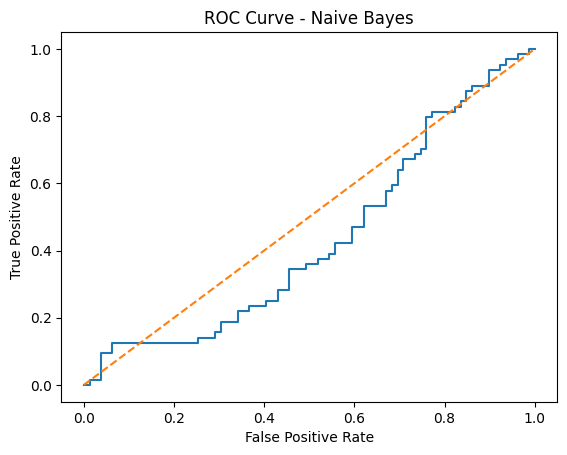

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

X = df['clean_review']
y = df['sentiment']

#split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Bag of Words
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

#Naive Bayes
model = MultinomialNB()
model.fit(X_train_bow, y_train)

#predictions
y_pred = model.predict(X_test_bow)
y_proba = model.predict_proba(X_test_bow)[:, 1]

#metrics
print("\n=== Naive Bayes Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

#ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.show()


3 Feature Selection Exercise.

3.1 Feature Selection using Wrapper Methods.
Dataset: Breast Cancer Prognostic Dataset


Objective
You are tasked with identifying the most important features in predicting breast cancer prognosis using the
Breast Cancer Prognostic Dataset from the UCI Machine Learning Repository. Apply a wrapper method
(Recursive Feature Elimination) to select the best features and evaluate your model’s performance.


Part 1: Data Loading and Preprocessing
1. Load the Breast Cancer Prognostic Dataset.
2. Dataset is available in Drive.
3. Perform basic exploratory data analysis (EDA) to understand the dataset:
• Summarize key statistics for each feature.
• Check for missing values and handle them appropriately.
4. Split the dataset into training (80%) and testing (20%) sets.


Part 2: Apply a Wrapper Method
1. Use Recursive Feature Elimination (RFE) with a Logistic Regression model to perform feature selection:
• Select the top 5 features that contribute the most to predicting the target variable.
• Visualize the ranking of features.
2. Train the Logistic Regression model using only the selected features.


Part 3: Model Evaluation
1. Evaluate the model’s performance using the testing set:
• Metrics to calculate: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
2. Compare the performance of the model trained on all features versus the model trained on the selected
features.


Part 4: Experiment
1. Experiment with different numbers of selected features (e.g., top 3, top 7).
2. Discuss how feature selection affects model performance.

Columns: Index(['Unnamed: 0', 'pid', 'age', 'meno', 'size', 'grade', 'nodes', 'pgr',
       'er', 'hormon', 'rfstime', 'status'],
      dtype='object')
   Unnamed: 0   pid  age  meno  size  grade  nodes  pgr  er  hormon  rfstime  \
0           1   132   49     0    18      2      2    0   0       0     1838   
1           2  1575   55     1    20      3     16    0   0       0      403   
2           3  1140   56     1    40      3      3    0   0       0     1603   
3           4   769   45     0    25      3      1    0   4       0      177   
4           5   130   65     1    30      2      5    0  36       1     1855   

   status  
0       0  
1       1  
2       0  
3       0  
4       0  

Summary statistics:
        Unnamed: 0          pid         age        meno        size  \
count  686.000000   686.000000  686.000000  686.000000  686.000000   
mean   343.500000   966.061224   53.052478    0.577259   29.329446   
std    198.175427   495.506249   10.120739    0.494355   14.296

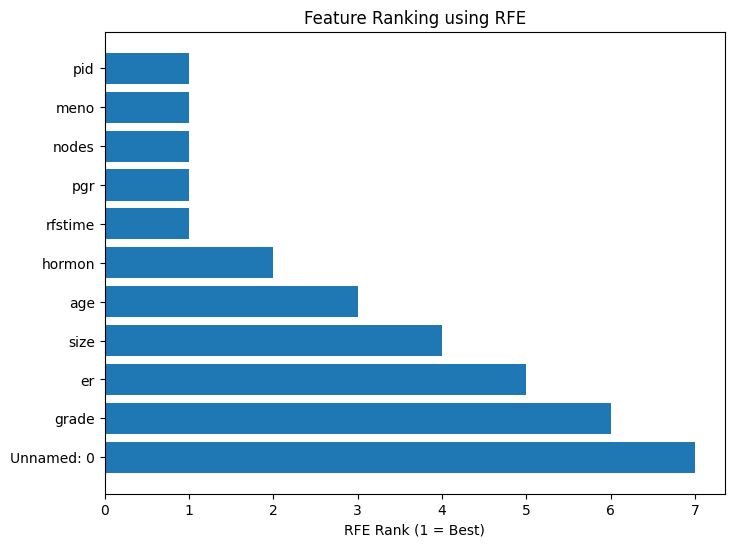


=== Model with All Features ===
Accuracy: 0.7608695652173914
Precision: 0.8245614035087719
Recall: 0.6714285714285714
F1-score: 0.7401574803149606
ROC-AUC: 0.8586134453781512
Confusion Matrix:
 [[58 10]
 [23 47]]

=== Model with Selected Features ===
Accuracy: 0.7463768115942029
Precision: 0.8181818181818182
Recall: 0.6428571428571429
F1-score: 0.72
ROC-AUC: 0.8527310924369748
Confusion Matrix:
 [[58 10]
 [25 45]]


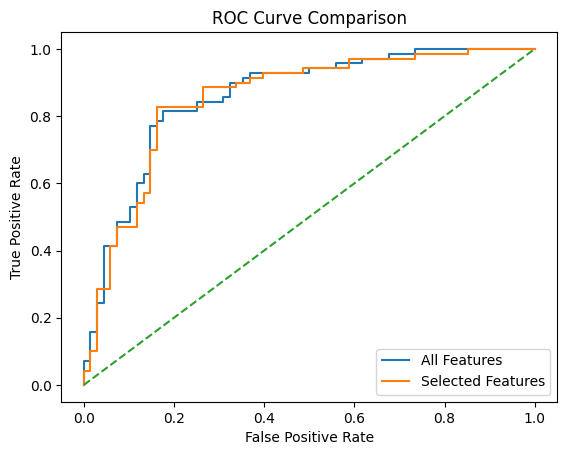


Accuracy with Top 3 features: 0.7753623188405797
Accuracy with Top 7 features: 0.7753623188405797


In [30]:
# 3.Feature Selection Exercise
#Dataset: Breast Cancer Prognostic


#Part 0: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

#Part 1: Load and Preprocess Data

#Load dataset
df = pd.read_csv("gbsg.csv")  # adjust path if needed
print("Columns:", df.columns)
print(df.head())

#Basic EDA
print("\nSummary statistics:\n", df.describe())
print("\nMissing values per column:\n", df.isnull().sum())

#Fill missing values with mean (if any)
df = df.fillna(df.mean(numeric_only=True))

#Split features and target
X = df.drop("status", axis=1)   # 'status' is target
y = df["status"]

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Part 2: Feature Selection using RFE
model = LogisticRegression(max_iter=1000)

#RFE: select top 5 features
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

#Selected features
selected_features = X.columns[rfe.support_]
print("\nTop 5 selected features:")
print(selected_features)

#Feature ranking
ranking = pd.DataFrame({
    "Feature": X.columns,
    "Rank": rfe.ranking_
}).sort_values("Rank")
print("\nFeature ranking:\n", ranking)

#Visualize ranking
plt.figure(figsize=(8,6))
plt.barh(ranking["Feature"], ranking["Rank"])
plt.xlabel("RFE Rank (1 = Best)")
plt.title("Feature Ranking using RFE")
plt.gca().invert_yaxis()
plt.show()

# Part 3: Model Training and Evaluation

#Model with ALL features
model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_train_scaled, y_train)
y_pred_all = model_all.predict(X_test_scaled)
y_proba_all = model_all.predict_proba(X_test_scaled)[:,1]

print("\n=== Model with All Features ===")
print("Accuracy:", accuracy_score(y_test, y_pred_all))
print("Precision:", precision_score(y_test, y_pred_all))
print("Recall:", recall_score(y_test, y_pred_all))
print("F1-score:", f1_score(y_test, y_pred_all))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_all))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_all))

#Model with SELECTED features
X_train_sel = X_train_scaled[:, rfe.support_]
X_test_sel = X_test_scaled[:, rfe.support_]

model_sel = LogisticRegression(max_iter=1000)
model_sel.fit(X_train_sel, y_train)
y_pred_sel = model_sel.predict(X_test_sel)
y_proba_sel = model_sel.predict_proba(X_test_sel)[:,1]

print("\n=== Model with Selected Features ===")
print("Accuracy:", accuracy_score(y_test, y_pred_sel))
print("Precision:", precision_score(y_test, y_pred_sel))
print("Recall:", recall_score(y_test, y_pred_sel))
print("F1-score:", f1_score(y_test, y_pred_sel))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_sel))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sel))

#ROC Curve Comparison
fpr_all, tpr_all, _ = roc_curve(y_test, y_proba_all)
fpr_sel, tpr_sel, _ = roc_curve(y_test, y_proba_sel)

plt.plot(fpr_all, tpr_all, label="All Features")
plt.plot(fpr_sel, tpr_sel, label="Selected Features")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Part 4: Experiment with Different Numbers of Features

#Top 3 features
rfe3 = RFE(model, n_features_to_select=3)
rfe3.fit(X_train_scaled, y_train)
X_train_3 = X_train_scaled[:, rfe3.support_]
X_test_3 = X_test_scaled[:, rfe3.support_]
model_3 = LogisticRegression(max_iter=1000)
model_3.fit(X_train_3, y_train)
y_pred_3 = model_3.predict(X_test_3)
print("\nAccuracy with Top 3 features:", accuracy_score(y_test, y_pred_3))

#Top 7 features
rfe7 = RFE(model, n_features_to_select=7)
rfe7.fit(X_train_scaled, y_train)
X_train_7 = X_train_scaled[:, rfe7.support_]
X_test_7 = X_test_scaled[:, rfe7.support_]
model_7 = LogisticRegression(max_iter=1000)
model_7.fit(X_train_7, y_train)
y_pred_7 = model_7.predict(X_test_7)
print("Accuracy with Top 7 features:", accuracy_score(y_test, y_pred_7))
